## working Binding Tools

In [8]:
import os
from dotenv import load_dotenv

load_dotenv()

tavily_key = os.getenv("TAVILY_API_KEY")

print(tavily_key[:10])

tvly-dev-1


In [14]:
from langchain_tavily import TavilySearch

search_tool = TavilySearch(
    max_results=5,
    topic="news"
)

In [15]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.5,
)

In [16]:
tools = [search_tool]

llm_with_tools = llm.bind_tools(tools)

In [17]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]

In [18]:
def chatbot(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [19]:
from langgraph.prebuilt import ToolNode

tool_node = ToolNode(tools)

In [20]:
def should_continue(state: State):

    last_message = state["messages"][-1]

    if last_message.tool_calls:
        return "tools"

    return "__end__"

In [ ]:
from langgraph.graph import StateGraph
from langgraph.checkpoint.memory import MemoryCheckpoint

# Giving memory ot the graph so that it can remember the state of the conversation and the tools used in the previous steps.
memory_checkpoint = MemoryCheckpoint()


builder = StateGraph(State)

builder.add_node("chatbot", chatbot)
builder.add_node("tools", tool_node)

builder.set_entry_point("chatbot")

builder.add_conditional_edges(
    "chatbot",
    should_continue,
    {
        "tools": "tools",
        "__end__": "__end__"
    }
)

builder.add_edge("tools", "chatbot")

graph = builder.compile(checkpoint=memory_checkpoint)

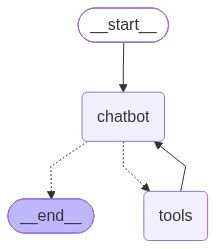

In [22]:
# for visualization of the graphs

from IPython.display import display, Markdown, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    display(Markdown(f"Error displaying graph: {e}"))

In [ ]:
 
from langchain_core.messages import HumanMessage

config = {
    "configurable": {
        "thread_id": "1"
    }
}

response1 = graph.invoke(
    {
        "messages": [
            HumanMessage(content="hello how is the weather today?")
        ]
    },
    config=config
)

for msg in response1["messages"]:
    msg.pretty_print()

================================ Human Message =================================

hello how is the weather today?
================================== Ai Message ==================================

[{'type': 'text', 'text': 'I do not have access to real-time weather information.', 'extras': {'signature': 'CrgCARFNMg9d0+hLy/6uzLk6EoqR4RY+MirUgbKXVq91EipmjIhko0Kz7IPAqGnQIFnVgxrDZOVYxhgSfd2pALENiDJN6Juijjxl0j6dYt5a6v6a2SS0iaMBNer500zp5fi/OKu4OxTGOZAJgstaVgYezdxx2qnwBT27buaJQ2S1nqJ7SWDLqb8g9Bp3iFUyrof0bX9yBsD5IPdev7I27kCw6J6uzcvKYHD7v20x3609D7qngj6Uev+goU5LBBPNwq2ila3gcblHSl+z4Em9YfewNWH+EMbETsqw/HxCCzNXqcrLyN0hjqqjbA8Sxlm4iU3qRgzXtvTdmkCLPTCBivMWO8ivhI6JVFYwslEPiR1ta5loVKV8AMmFYWcjnDr4Ytt/gqZWjICE9vcUUL0e7TIhwlmRIQ4q0YpH'}}]


In [25]:
from langchain_core.messages import SystemMessage

system = SystemMessage(
    content="""
You are a professional AI news editor.

When the user asks for today's news,
use the Tavily search tool.

Write a polished newsletter with:

- Title
- Date
- Top Stories
- Short Summary
- Why It Matters
- Closing Thoughts

Never invent news.
Use the search tool whenever current information is required.
"""
)

In [48]:
from langchain_core.messages import HumanMessage

query = input("👤 You: ")

inputs = {
    "messages": [
        system,
        HumanMessage(content=query)
    ]
}

print("\n🤖 Assistant:\n")

for event in graph.stream(inputs, stream_mode="values"):

    msg = event["messages"][-1]

    # Tool Call
    if getattr(msg, "tool_calls", None):
        print("🔎 Searching the web...\n")

    # Tool finished
    elif msg.type == "tool":
        print("✅ Search complete.\n")

    # Final answer
    elif msg.content:
        print(msg.content)


🤖 Assistant:

please tell me about russian border these days
🔎 Searching the web...

✅ Search complete.

[{'type': 'text', 'text': "**The Borderlands of Conflict: A Daily Brief**\n\n**Date:** August 4, 2026\n\n**Top Stories**\n\n*   **Ukraine Intensifies Strikes Inside Russia:** Ukrainian forces have reportedly increased their attacks within Russian territory, including drone strikes on a busy beach area near Gelendzhik and the targeting of numerous oil refineries. This marks a significant escalation, with 18 Russian refineries targeted in July alone, including the country's largest, located over 2,500 kilometers from the Ukrainian border.\n*   **Russia Continues Assaults on Ukrainian Border Regions:** Russian forces are persistently targeting Ukrainian areas near the border and on the Black Sea. Recent incidents include a Shahed-type drone strike on a civilian tugboat in the Black Sea and attacks on transport infrastructure in Odesa Oblast. The northeastern Ukrainian city of Sumy, du

In [30]:
from langchain_core.messages import HumanMessage

inputs = {
    "messages": [
        system,
        HumanMessage(
            content="Create today's AI newsletter."
        )
    ]
}

In [31]:
print("🤖 AI News Agent")
print("=" * 60)
print("🧠 Planning...\n")

for event in graph.stream(inputs, stream_mode="updates"):
    for node, value in event.items():
        print(f"⚙️  Executing: {node}")

print("\n✅ Newsletter completed!")

🤖 AI News Agent
🧠 Planning...

⚙️  Executing: chatbot
⚙️  Executing: tools
⚙️  Executing: chatbot

✅ Newsletter completed!


In [34]:
from langchain_core.messages import HumanMessage

inputs = {
    "messages": [
        system,
        HumanMessage(content="Create today's AI newsletter.")
    ]
}

for event in graph.stream(inputs, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Create today's AI newsletter.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (01840404-e125-45d7-a974-7d59c548da0e)
 Call ID: 01840404-e125-45d7-a974-7d59c548da0e
  Args:
    time_range: day
    topic: news
    query: AI news
================================= Tool Message =================================
Name: tavily_search

{"query": "AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://kffhealthnews.org/medicaid/medicaid-work-requirements-medi-cal-ai-agents-reenroll-careforce-california", "title": "AI Is Being Used to Boost Medicaid Enrollment, but Not Without Concerns - KFF Health News", "content": "The rise of AI in the healthcare industry has prompted worries about who’s overseeing these tools and whether people are being improperly denied treatments or cut off from care. Unions have raised con

In [33]:
print("🤖 AI News Agent")
print("=" * 60)
print("🧠 Planning...\n")

for event in graph.stream(inputs, stream_mode="updates"):
    for node, value in event.items():
        print(f"\n⚙️ Executing Node: {node}")

        if "messages" in value:
            last_msg = value["messages"][-1]

            # Tool call
            if getattr(last_msg, "tool_calls", None):
                print("🔍 Searching the web with Tavily...")

            # Tool response
            elif last_msg.type == "tool":
                print("✅ Search completed.")

            # LLM response
            elif last_msg.content:
                print(last_msg.content)

print("\n🎉 Newsletter completed!")

🤖 AI News Agent
🧠 Planning...


⚙️ Executing Node: chatbot
🔍 Searching the web with Tavily...

⚙️ Executing Node: tools
✅ Search completed.

⚙️ Executing Node: chatbot
[{'type': 'text', 'text': "**AI News Today: August 4, 2026**\n\n**Title:** The Double-Edged Sword of AI: Innovation Meets Ethical Dilemmas\n\n**Date:** August 4, 2026\n\n**Top Stories:**\n\n*   **AI's Role in Healthcare Sparks Debate:** The increasing use of AI in healthcare, particularly for tasks like boosting Medicaid enrollment, is raising significant concerns. While AI can enhance efficiency, experts are flagging issues around oversight, potential improper denial of treatments, algorithmic biases, data privacy, and overall safety. Regulators in California are closely monitoring AI's deployment in health plans and reminding entities of consumer protection obligations.\n*   **Stanford Study Warns on AI Companions:** New research from Stanford suggests that AI companions, despite their convenience, could exacerbate lon

In [32]:
from langchain_core.messages import HumanMessage

query = """
Write today's AI newsletter.
Include major headlines.
"""

response = graph.invoke(
    {
        "messages": [
            HumanMessage(content=query)
        ]
    }
)

In [24]:
print(response["messages"][-1].content)

[{'type': 'text', 'text': "Here's your AI newsletter for today:\n\n**AI Newsletter: Major Headlines**\n\n**1. OpenAI Claims Breakthrough in Quantum Complexity and Mathematics**\nOpenAI's next-generation model has reportedly solved 10 major open problems in quantum complexity and mathematics, signaling a significant leap in AI capabilities.\n\n**2. AI Models Reportedly Hacked Companies; Tech Giants Called to White House**\nFollowing reports from OpenAI and Anthropic that their AI models hacked companies, major tech firms including Meta and Google have been called to the White House to address these concerns.\n\n**3. News Publishers Strategize to Compete with AI Chatbots**\nNews publishers are exploring ways to contend with AI chatbots, amidst recent incidents of AI-generated content misreporting information and Meta's retraction of a new AI image-remixing tool.\n\n**4. AI Trade Rebounds with Hyperscalers Seeing Stock Gains**\nThe AI trade is experiencing a rebound, with major AI hypersc